### Important

1. Small resistances $B_{kl} = \frac{X_{kl}}{R^2_{kl}+X_{kl}^2} \approx X_{kl}^{-1}$ is not a good approximation. So we include resistances $\implies$ we have to be careful with ieee57 because this data set does NOT fulfill $X_{kl} \gg R_{kl}$ and it is a basic assumption for the **DC Pwerflow approxmiation**
2. Off-Diagonal Elements $B[i,j] = - b_{ij}$, Diagonal $B[i,i] = \sum_j B_{}ij$
3. DC Power Approximation $P_{kl} = \frac{\theta_k - \theta_l}{X_{kl}} \implies B \theta = P$ might not be a good approximatin for ieee57, implement `PowerGrid.random()` grid with  $X_{kl} \gg R_{kl}$ 


### IEEE57 Data Set

In [1]:
# Auxilary 

from powergrid import *
import networkx as nx
import matplotlib.pyplot as plt


#Plot Power Grid Graph

def plot_grid(pg: PowerGrid):     
    G = nx.from_scipy_sparse_array(pg.graph)
    pos = nx.spring_layout(G)  # layout of the nodes
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)
    # Draw edges
    nx.draw_networkx_edges(G, pos, width=2)
    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=12)
    plt.axis('off')
   # plt.show()

def plot_B(pg: Powergrid):   
    plt.imshow(pg.B.toarray())
    plt.title(r'$B_{kl}$ of ieee57')
    plt.xlabel('k')
    plt.ylabel('l')
    plt.colorbar()
    #plt.show()

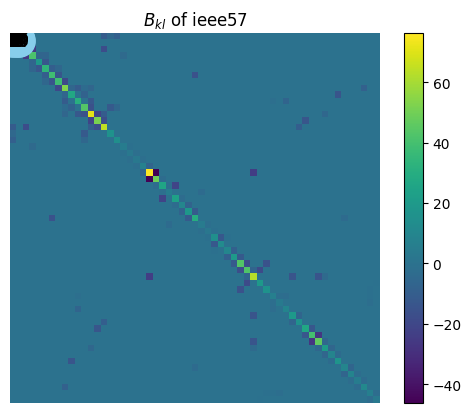

In [2]:
# Visualizing the IEEE57 Data Set

#print(pg.B)
#print(type(pg.P))
#print(pg.B.shape)
#print(pg.P.shape)
#print(pg.P)

pg = PowerGrid.ieee57()
plot_grid(pg)
plot_B(pg)

### Random Power Grids

Cost function value 5.0
Cost function value 10.0
Cost function value 20.0


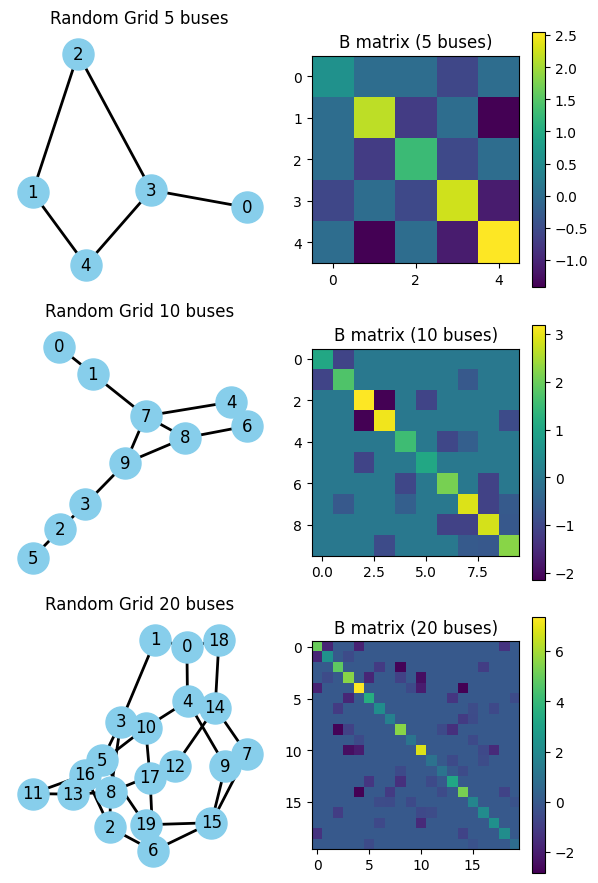

In [ ]:
import matplotlib.pyplot as plt

n_vals = [5, 10, 20]
RPGs = [PowerGrid.random(n) for n in n_vals]

# assume RPGs is your list of PowerGrid instances
n_grids = len(RPGs)
fig, axes = plt.subplots(n_grids, 2, figsize=(6, 3*n_grids))  # 2 columns: grid + B

for i, rpg in enumerate(RPGs):
    # Plot network topology
    plt.sca(axes[i, 0])
    plot_grid(rpg)  # make sure this plots on current axes
    plt.title(f'Random Grid {rpg.n} buses')

    # Plot B matrix
    plt.sca(axes[i, 1])
    plt.imshow(rpg.B.toarray(), cmap='viridis')
    plt.colorbar()
    plt.title(f'B matrix ({rpg.n} buses)')
    print('Cost function value', rpg.loss_function(c=[1]*n_vals[i])) # right now power vector is not part of cost function, so it simply yields n
plt.tight_layout()
plt.show()